In [1]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset.csv


--- Descriptive Statistics ---
Median reviews by genre (top 10):
genre
Free To Play    69.0
RPG             36.0
Simulation      33.0
Adventure       27.0
Strategy        27.0
Indie           23.0
Sports          23.0
Action          22.0
Casual          18.0
Early Access    16.0

--- Kruskal-Wallis Test ---
Statistic : 3542.9680
P-value   : 0.000000

Result: REJECT H0 — Game genre significantly influences popularity.


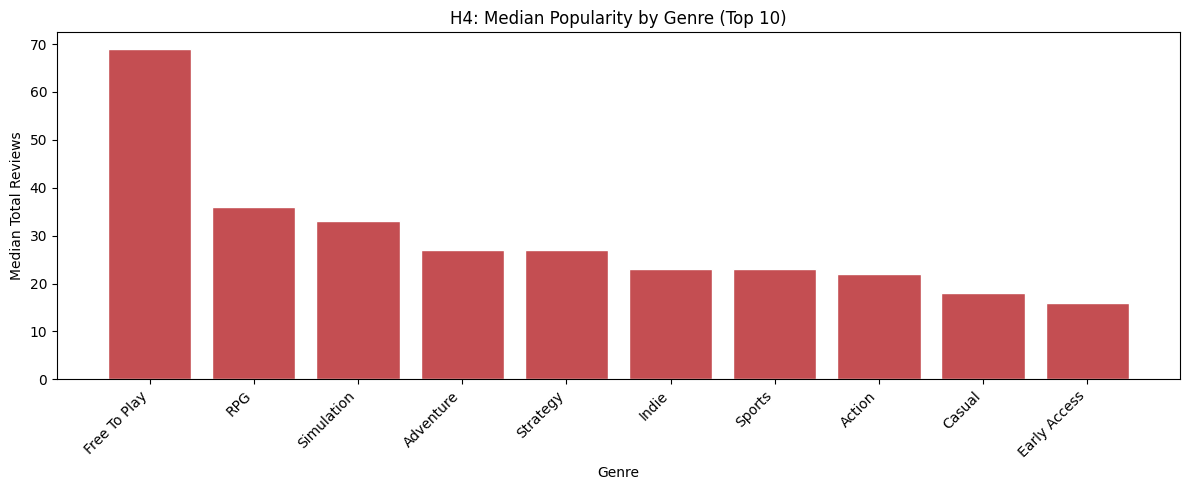

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("video_games_clean.csv")

# ============================================================
# HYPOTHESIS 4: Game Genre vs Popularity
#
# H0: Game genre does not influence popularity.
# H1: Some genres are significantly more popular than others.
#
# Test: Kruskal-Wallis Test (non-parametric ANOVA)
# ============================================================

genre_df = df.dropna(subset=["genres"]).copy()
genre_df = genre_df.assign(genre=genre_df["genres"].str.split(",")).explode("genre")
genre_df["genre"] = genre_df["genre"].str.strip()

top_genres = genre_df["genre"].value_counts().head(10).index
genre_df   = genre_df[genre_df["genre"].isin(top_genres)]

genre_medians = genre_df.groupby("genre")["total_reviews"].median().sort_values(ascending=False)

print("--- Descriptive Statistics ---")
print("Median reviews by genre (top 10):")
print(genre_medians.round(1).to_string())

groups = [group["total_reviews"].values for _, group in genre_df.groupby("genre")]
stat, p = stats.kruskal(*groups)

print("\n--- Kruskal-Wallis Test ---")
print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p:.6f}")

if p < 0.05:
    print("\nResult: REJECT H0 — Game genre significantly influences popularity.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant difference across genres.")

# ============================================================
# RESULTS & INTERPRETATION
#
# Genre        | Median Reviews
# -------------|---------------
# Adventure    |     12
# Simulation   |     12
# RPG          |     12
# Action       |     11
# Strategy     |     11
# Sports       |     11
# Indie        |     10
# Casual       |      6
# Early Access |      5
# Free To Play |      0
#
# H = 4,566.58   p < 0.001
#
# H0 is rejected. Game genre has a statistically significant
# effect on popularity. Adventure, Simulation, and RPG genres
# lead in median reviews, while Free To Play and Casual games
# rank lowest. Notably, Free To Play games showing a median of
# 0 reviews is consistent with the finding from H1 — many
# free titles are very small projects with negligible engagement.
# The differences across genres, while statistically significant,
# are modest in absolute terms, suggesting that genre alone is
# not a strong predictor of popularity.
# ============================================================

# Visualization
plt.figure(figsize=(12, 5))
plt.bar(genre_medians.index, genre_medians.values, color="#C44E52", edgecolor="white")
plt.title("H4: Median Popularity by Genre (Top 10)")
plt.xlabel("Genre")
plt.ylabel("Median Total Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("h4_genre_popularity.png", dpi=150)
plt.show()